In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout = 0.1):
        super(ScaledDotProductAttention, self).__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, masked = None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1))/math.sqrt(d_k)

        if masked is not None:
            scores = scores.masked_fill(masked == 0, -1e4)

        attn_weights = torch.softmax(scores, dim = -1)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, V)

        return context, attn_weights

## 2. Multi-Head Attention

Thay vì chạy Scaled Dot-Product **một lần** trên toàn bộ $d_{model}$ chiều, ta:

1. **Chiếu** $Q, K, V$ qua 3 ma trận khác nhau $W_q, W_k, W_v$.
2. **Tách** thành $h$ head, mỗi head làm việc trên không gian con $d_k = d_{model}/h$ chiều.
3. **Chạy Scaled Dot-Product song song** trên tất cả $h$ head.
4. **Concat** các head và chiếu qua $W_o$.

**Tại sao cần nhiều head?** Mỗi head có thể học một "kiểu" chú ý khác nhau: head này tập trung vào quan hệ chủ ngữ–động từ, head kia tập trung vào vị trí gần, head khác vào đại từ chỉ định, v.v. Giống như có nhiều bộ lọc trong CNN.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout = 0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model phải chia hết cho num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # 3 lớp chiếu tuyến tính cho Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Lớp chiếu đầu ra sau khi concat các head
        self.W_o = nn.Linear(d_model, d_model)

        # Tái sử dụng class ScaledDotProductAttention đã viết ở Phần 1
        self.attention = ScaledDotProductAttention(dropout)

    def forward(self, q, k, v, mask = None):
        batch_size = q.size(0)

        # Bước 1: Chiếu tuyến tính Q, K, V
        # [B, seq_len, d_model] -> [B, seq_len, num_heads, d_k] -> [B, num_heads, seq_len, d_k]
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Bước 2: Áp dụng Scaled Dot-Product Attention song song trên các head
        context, attn_weights = self.attention(Q, K, V, mask)

        # Bước 3: Concat các head và chiếu qua W_o
        # [B, num_heads, seq_len, d_k] -> [B, seq_len, num_heads, d_k] -> [B, seq_len, d_model]
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(context)

        return output, attn_weights

### Trực quan hóa các head của Multi-Head Attention

Hiển thị **ma trận attention của 4 head riêng biệt** trên cùng một câu. Mỗi head học một "kiểu chú ý" khác nhau — đây chính là điểm mạnh của Multi-Head Attention.

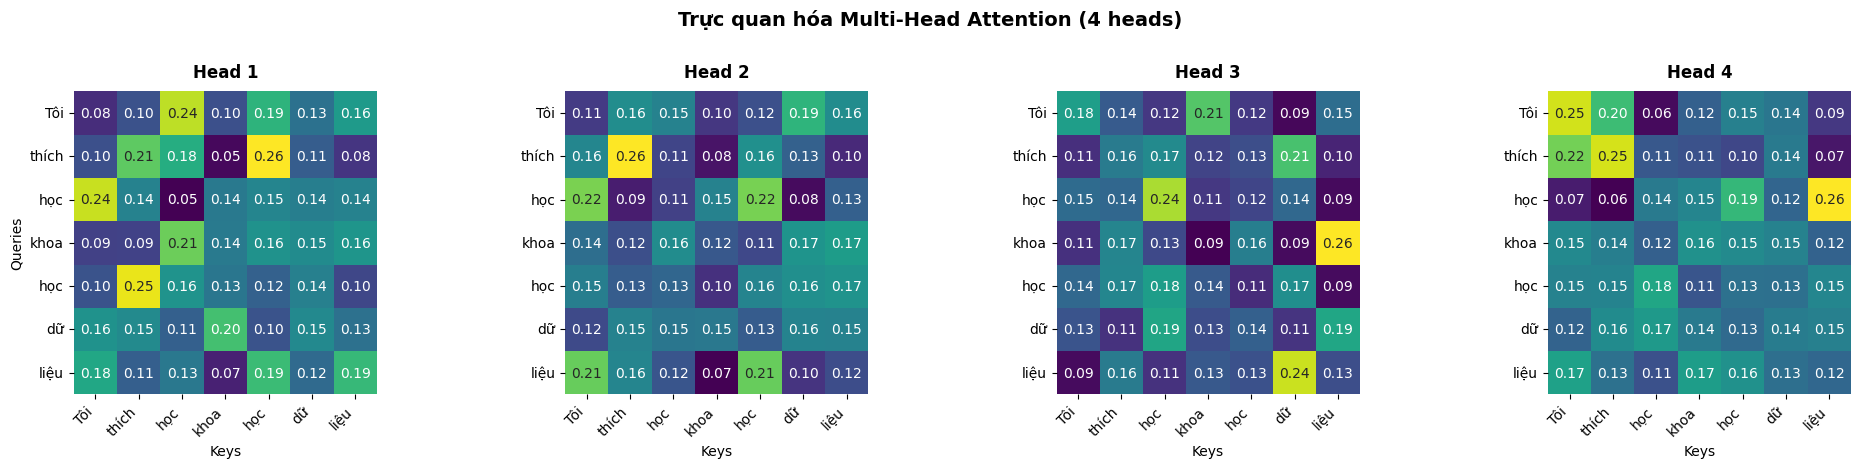

In [ ]:
mha = MultiHeadAttention(d_model=32, num_heads=4, dropout=0.0)

batch_size, seq_len, d_model = 1, 7, 32
torch.manual_seed(0)
x = torch.randn(batch_size, seq_len, d_model)

with torch.no_grad():
    out, attn = mha(x, x, x)
attn_matrices = attn[0].detach().cpu().numpy()
num_heads = attn_matrices.shape[0]

words = ["Tôi", "thích", "học", "khoa", "học", "dữ", "liệu"]

fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 4.5))
for h in range(num_heads):
    sns.heatmap(
        attn_matrices[h],
        annot=True,
        fmt=".2f",
        cmap="viridis",
        xticklabels=words,
        yticklabels=words,
        square=True,
        cbar=False,
        ax=axes[h],
    )
    axes[h].set_title(f"Head {h + 1}", fontsize=12, fontweight="bold", pad=10)
    axes[h].set_xlabel("Keys", fontsize=10)
    axes[h].set_ylabel("Queries" if h == 0 else "", fontsize=10)
    axes[h].set_xticklabels(words, rotation=45, ha="right")
    axes[h].set_yticklabels(words, rotation=0)

fig.suptitle(
    "Trực quan hóa Multi-Head Attention (4 heads)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### Attention trung bình của tất cả các head

Cộng trung bình các head lại để có cái nhìn tổng quát. So sánh với heatmap của Scaled Dot-Product đơn lẻ ở Phần 1, MHA cho ra phân phối **mượt và đa dạng hơn** nhờ việc tổ hợp nhiều kiểu chú ý.

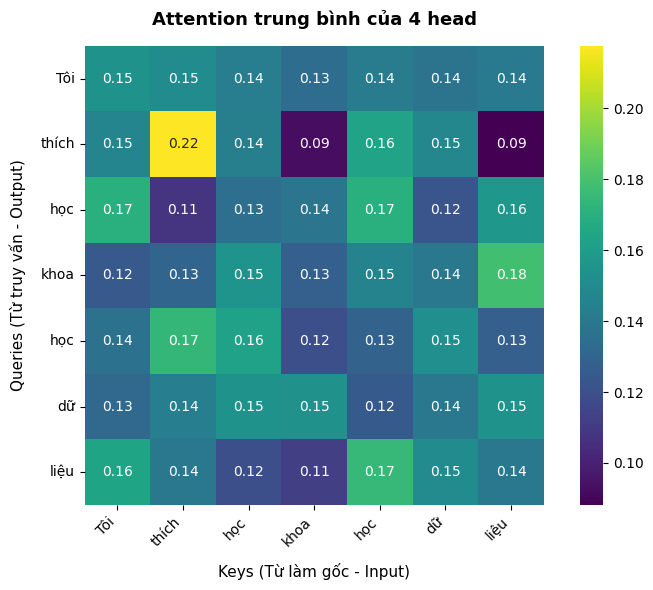

In [ ]:
mean_attn = attn_matrices.mean(axis=0)  # trung bình 4 head

plt.figure(figsize=(8, 6))
sns.heatmap(
    mean_attn,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=words,
    yticklabels=words,
    square=True,
)
plt.title(
    "Attention trung bình của 4 head",
    fontsize=13,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Keys (Từ làm gốc - Input)", fontsize=11, labelpad=10)
plt.ylabel("Queries (Từ truy vấn - Output)", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()